In [1]:
!"C:/Users/alex/AppData/Local/Programs/Python/Python312/python.exe" -m pip install sacrebleu

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import torch
import torch.nn as nn
import pandas as pd
import sentencepiece
from tqdm import tqdm
import comet_ml
import sacrebleu
from torch.utils.data import DataLoader

In [4]:
from dataset import WordTokenizer, TextDataset

In [5]:
tokenizer_en = WordTokenizer().fit("data/train.de-en.en")
tokenizer_de = WordTokenizer().fit("data/train.de-en.de")

In [6]:
dataset = TextDataset("data/train.de-en.de", "data/train.de-en.en", min_samples=30)

In [7]:
# train_data, _ = train_test_split(dataset, test_size=0.7)

In [37]:
from model import LanguageModel

In [26]:
from train import train

In [51]:
loader = DataLoader(dataset, 128, True, pin_memory=True, num_workers=2)

In [48]:
model = LanguageModel(dataset, embed_size=256, hidden_size=512, rnn_layers=2, rnn_type=nn.LSTM)
model.to("cuda")           

LanguageModel(
  (embedding_en): Embedding(6136, 256, padding_idx=0)
  (embedding_de): Embedding(6494, 256, padding_idx=0)
  (rnn_encoder): LSTM(256, 512, num_layers=2, batch_first=True)
  (rnn_decoder): LSTM(768, 512, num_layers=2, batch_first=True)
  (linear): Linear(in_features=512, out_features=6136, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

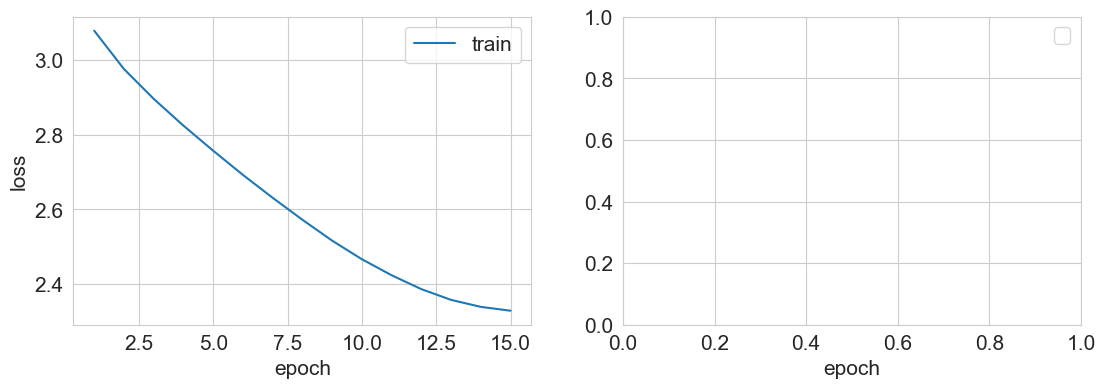

Generation examples:
Doich: als ich ein kleines mädchen war – und ich wuchs in einer <unk> gemeinde auf , es war eine <unk> gemeinde der <unk> – und es gab dort all die fallen und den <unk> eines perfekten , wundervollen lebens . <eos>                                                                                     
Eng: <unk> <unk> <unk> <unk> <unk> , <unk> <unk> <unk> somebody of pink <unk> <unk> 's <unk> national village , the past <unk> <unk> private horse <unk> new city of anonymous communities as fathers <unk> <unk> to fill crazy software workers , so they 'd come up with various [ good intellectual <unk> illegal <unk> in the gallery that the whole <unk> corporation is the big <unk> <unk> journal , highly <unk> gay problems behind embodied realities trade , abundant <unk> <unk> all of a successful <unk> useful decision in prison such as bill or <unk> organizations at countless media bubbles in the bible at the same <unk> moment whether these <unk> labeled , <unk> <unk> <unk> a

In [52]:
optimizer   = torch.optim.Adam(model.parameters(), 1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, 15)
   
train(model, optimizer, train_loader=loader, scheduler=scheduler, val_loader=loader, num_epochs=15 )

In [53]:
torch.save(model.state_dict(), "check_lstm.pth")

In [54]:
cnt = 0
with open("data/test1.de-en.de", "r", encoding="utf-8") as f_in:
    with open("data/test1_lstm.de-en.en", "w", encoding="utf-8") as f_out:
        for line in f_in.readlines():
            new_line = model.inference(line, temp=0.3)
            if new_line[-1] != "\n":
                new_line += "\n"
            f_out.write(new_line)
            cnt += 1